In [25]:
import os, base64
from dotenv import load_dotenv
from snowflake import connector as snowflake_connector
from snowflake.snowpark.session import Session

load_dotenv('.env')

# creds = {
#     'account':     os.getenv('SNOWFLAKE_ACCOUNT'),
#     'warehouse':   os.getenv('SNOWFLAKE_WAREHOUSE'),
#     'role':        os.getenv('SNOWFLAKE_ROLE'),
#     'user':        os.getenv('SNOWFLAKE_USERNAME'),
#     'private_key': base64.b64decode(os.getenv('SNOWFLAKE_PRIVATE_KEY')),
# }
# print(creds)
# # 1. The classic connector — for raw SQL + polars.read_database
# snowflake_connection = snowflake_connector.connect(**creds)

snowflake_connection = snowflake_connector.connect(**{
     'account': os.getenv('SNOWFLAKE_ACCOUNT'),
     'warehouse': os.getenv('SNOWFLAKE_WAREHOUSE'),
     'role': os.getenv('SNOWFLAKE_ROLE'),
     'user': os.getenv('SNOWFLAKE_USERNAME'),
     'private_key': base64.b64decode(os.getenv('SNOWFLAKE_PRIVATE_KEY'))
})

# # 2. The Snowpark session — for the DataFrame API
snowpark_session = Session.builder.configs(creds).create()

In [26]:
import polars as pl

(
    pl.read_database(
        """
        SELECT *
        FROM LISTED_INTERN_PROJECT.PROJECT_COMMON.BINNED_DATA
        LIMIT 10
        """,
        snowflake_connection,
    )
    # Snowflake returns ALL CAPS column names — normalize them
    .select(pl.all().name.to_lowercase())
)

qcode,publication_date,security,bin_start_time,gmt_offset_hours,open,high,low,close,twa_bid_size,twa_ask_size,bid_size_start,bid_size_end,ask_size_start,ask_size_end,volume,signed_volume,trade_count,vwap,twa_bid,twa_ask,bid_start,bid_end,ask_start,ask_end
str,date,str,time,f64,f64,f64,f64,f64,f64,f64,i32,i32,i32,i32,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64
"""UG""",2021-02-05,"""WN2021H Comdty""",14:15:00,-6.0,200.375,200.40625,200.28125,200.34375,75.468687,68.109347,24,68,171,64,878,355,178,200.337842,200.323602,200.355292,200.375,200.3125,200.40625,200.34375
"""GM""",2021-06-22,"""OE2021U Comdty""",12:50:00,2.0,134.0,134.01,133.99,133.99,1615.601657,2484.679653,1865,2700,2489,1508,4999,2005,62,133.999946,133.99746,134.00746,134.0,133.99,134.01,134.0
"""GC""",2021-10-05,"""GC2021Z Comdty""",08:45:00,-4.0,1758.9,1759.9,1758.2,1758.3,7.86805,7.896997,1,8,7,6,804,-39,363,1759.093408,1758.855649,1758.981858,1758.9,1758.2,1759.0,1758.3
"""TT""",2021-08-31,"""TP2021U Index""",12:50:00,9.0,1952.5,1957.5,1952.0,1957.5,69.41374,69.347557,63,72,28,8,1174,856,274,1954.763203,1953.639358,1954.15775,1952.0,1957.0,1952.5,1957.5
"""HN""",2021-09-09,"""XU2021U Index""",11:35:00,8.0,15263.0,15272.0,15263.0,15269.0,23.225733,11.916113,4,14,8,13,537,36,282,15267.793296,15266.098943,15267.395643,15263.0,15267.0,15265.0,15270.0
"""FX""",2021-07-14,"""VG2021U Index""",12:25:00,2.0,4077.5,4080.0,4076.0,4077.5,149.49833,134.076733,110,76,229,190,2645,1481,176,4078.683554,4077.215973,4077.741842,4077.5,4077.5,4078.0,4078.0
"""TY""",2021-12-27,"""TY2022H Comdty""",09:50:00,-6.0,130.609375,130.625,130.59375,130.609375,1532.4901,1482.631473,1478,1940,1683,441,6229,579,370,130.613213,130.606847,130.622477,130.609375,130.609375,130.625,130.625
"""PI""",2021-04-12,"""XP2021M Index""",12:55:00,10.0,6938.0,6939.0,6936.0,6937.0,11.0354,9.184683,3,19,13,7,87,5,63,6936.954023,6936.536157,6937.60802,6938.0,6936.0,6939.0,6937.0
"""HG""",2021-10-28,"""HG2021Z Comdty""",05:05:00,-4.0,4.4385,4.443,4.4375,4.4395,3.40383,3.140397,3,4,3,2,176,9,104,4.439517,4.440269,4.441199,4.438,4.4385,4.439,4.4395


---

## Extract all tables → `data/raw/`

Pull the four tables from `LISTED_INTERN_PROJECT.PROJECT_COMMON` and save each as a CSV in `data/raw/`:

| Table | Description |
|---|---|
| `BINNED_DATA` | 5-minute bin OHLC + microstructure data for front-month contracts |
| `QCODE_MAPPING` | Curve identifier (`qcode`) descriptions |
| `SECURITY_META` | Meta information for all outright contracts |
| `TRADE_LIST` | Individual trade records |

Each table is read in full via the raw connector and written to `data/raw/<table>.csv`.

In [27]:
# import polars as pl
# from pathlib import Path

# RAW_DIR = Path("data/raw")
# RAW_DIR.mkdir(parents=True, exist_ok=True)

# SCHEMA = "LISTED_INTERN_PROJECT.PROJECT_COMMON"
# TABLES = ["BINNED_DATA", "QCODE_MAPPING", "SECURITY_META", "TRADE_LIST"]

# for table in TABLES:
#     df = pl.read_database(
#         f"SELECT * FROM {SCHEMA}.{table}",
#         snowflake_connection,
#     ).select(pl.all().name.to_lowercase())  # normalize ALL CAPS column names

#     out_path = RAW_DIR / f"{table.lower()}.csv"
#     df.write_csv(out_path)
#     print(f"{table}: {df.shape[0]:,} rows x {df.shape[1]} cols -> {out_path}")


---

## Preview each table (direct from Snowflake)

Read a few rows of every table straight from `LISTED_INTERN_PROJECT.PROJECT_COMMON` (not from the CSVs) to sanity-check the structure.

In [28]:
import polars as pl

pl.Config.set_tbl_cols(-1)  # show all columns

SCHEMA = "LISTED_INTERN_PROJECT.PROJECT_COMMON"
TABLES = ["BINNED_DATA", "QCODE_MAPPING", "SECURITY_META", "TRADE_LIST"]

for table in TABLES:
    df = pl.read_database(
        f"SELECT * FROM {SCHEMA}.{table} LIMIT 5",
        snowflake_connection,
    ).select(pl.all().name.to_lowercase())
    print(f"\n{'='*80}\n{table}  (showing 5 rows, {df.width} columns)\n{'='*80}")
    print(df)



BINNED_DATA  (showing 5 rows, 25 columns)
shape: (5, 25)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ qco ┆ pub ┆ sec ┆ bin ┆ gmt ┆ ope ┆ hig ┆ low ┆ clo ┆ twa ┆ twa ┆ bid ┆ bid ┆ ask ┆ ask ┆ vol ┆ sig ┆ tra ┆ vwa ┆ twa ┆ twa ┆ bid ┆ bid ┆ ask ┆ ask │
│ de  ┆ lic ┆ uri ┆ _st ┆ _of ┆ n   ┆ h   ┆ --- ┆ se  ┆ _bi ┆ _as ┆ _si ┆ _si ┆ _si ┆ _si ┆ ume ┆ ned ┆ de_ ┆ p   ┆ _bi ┆ _as ┆ _st ┆ _en ┆ _st ┆ _en │
│ --- ┆ ati ┆ ty  ┆ art ┆ fse ┆ --- ┆ --- ┆ f64 ┆ --- ┆ d_s ┆ k_s ┆ ze_ ┆ ze_ ┆ ze_ ┆ ze_ ┆ --- ┆ _vo ┆ cou ┆ --- ┆ d   ┆ k   ┆ art ┆ d   ┆ art ┆ d   │
│ str ┆ on_ ┆ --- ┆ _ti ┆ t_h ┆ f64 ┆ f64 ┆     ┆ f64 ┆ ize ┆ ize ┆ sta ┆ end ┆ sta ┆ end ┆ i32 ┆ lum ┆ nt  ┆ f64 ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- │
│     ┆ dat ┆ str ┆ me  ┆ our ┆     ┆     ┆     ┆     ┆ --- ┆ --- ┆ rt  ┆ --- ┆ rt  ┆ --- ┆     ┆ e   ┆ --- ┆     ┆ f64 ┆ f64 ┆ f64 ┆ f64 ┆ f64 ┆ f64 │
│     ┆ e   ┆     ┆ --- ┆ s   

---

## How does `TRADE_LIST` look?

Inspecting the table directly (queries below) shows:

- **Columns:** `security`, `date`, `trade_list`, `side`, `quantity` — 5 columns, ~790,776 rows.
- **It spans many days, not one.** Dates run from **2016-01-04 to 2026-04-30** (2,687 distinct trading days) across **3,445 distinct securities** (one per front-month contract over time).
- **Grain = exactly 6 rows per `(security, date)`.** Every security/day has one row for each combination of size bucket × side:

  | `trade_list` | `side` | typical qty (example day) |
  |---|---|---|
  | `small_buys`   | buy  | 333    |
  | `small_sells`  | sell | 333    |
  | `medium_buys`  | buy  | 3,330  |
  | `medium_sells` | sell | 3,330  |
  | `large_buys`   | buy  | 33,298 |
  | `large_sells`  | sell | 33,298 |

- The size buckets are roughly **10× apart** (small → medium → large), and on a given day the **buy and sell quantities mirror each other** within each bucket. So this isn't a log of actual market prints — it's a structured per-day, per-security **trade schedule** (how much you'd buy/sell in small/medium/large clips), keyed to a `(security, date)` you can join back to `BINNED_DATA` for execution prices.

The cells below reproduce these findings against Snowflake.

In [29]:
TL = "LISTED_INTERN_PROJECT.PROJECT_COMMON.TRADE_LIST"

# Date span + coverage
print(pl.read_database(
    f"""SELECT MIN(date) AS first_date, MAX(date) AS last_date,
               COUNT(DISTINCT date) AS n_days,
               COUNT(DISTINCT security) AS n_securities,
               COUNT(*) AS n_rows
        FROM {TL}""",
    snowflake_connection,
).select(pl.all().name.to_lowercase()))

# The 6 categories
print(pl.read_database(
    f"""SELECT trade_list, side, COUNT(*) AS n, SUM(quantity) AS total_qty
        FROM {TL} GROUP BY 1, 2 ORDER BY 1, 2""",
    snowflake_connection,
).select(pl.all().name.to_lowercase()))

# One full security/day = exactly 6 rows
print(pl.read_database(
    f"""SELECT * FROM {TL}
        WHERE security = 'IK2026M Comdty' AND date = '2026-03-06'
        ORDER BY trade_list""",
    snowflake_connection,
).select(pl.all().name.to_lowercase()))


shape: (1, 5)
┌────────────┬────────────┬────────┬──────────────┬────────┐
│ first_date ┆ last_date  ┆ n_days ┆ n_securities ┆ n_rows │
│ ---        ┆ ---        ┆ ---    ┆ ---          ┆ ---    │
│ date       ┆ date       ┆ i64    ┆ i64          ┆ i32    │
╞════════════╪════════════╪════════╪══════════════╪════════╡
│ 2016-01-04 ┆ 2026-04-30 ┆ 2687   ┆ 3445         ┆ 790776 │
└────────────┴────────────┴────────┴──────────────┴────────┘
shape: (6, 4)
┌──────────────┬──────┬────────┬────────────┐
│ trade_list   ┆ side ┆ n      ┆ total_qty  │
│ ---          ┆ ---  ┆ ---    ┆ ---        │
│ str          ┆ str  ┆ i64    ┆ i64        │
╞══════════════╪══════╪════════╪════════════╡
│ large_buys   ┆ buy  ┆ 131796 ┆ 3026686292 │
│ large_sells  ┆ sell ┆ 131796 ┆ 3026686292 │
│ medium_buys  ┆ buy  ┆ 131796 ┆ 302668873  │
│ medium_sells ┆ sell ┆ 131796 ┆ 302668873  │
│ small_buys   ┆ buy  ┆ 131796 ┆ 30266773   │
│ small_sells  ┆ sell ┆ 131796 ┆ 30266773   │
└──────────────┴──────┴────────┴───────

---

## Does `BINNED_DATA` start before `TRADE_LIST`?

**No — the date spans are identical.** Both tables run **2016-01-04 → 2026-04-30** over the same **2,687 trading days** and the same **3,445 securities**. Neither leads the other; they're a matched pair, so every `(security, date)` in the trade schedule has price bins to execute against.

`BINNED_DATA` is ~13.05M rows across 50 qcodes, spread evenly at ~260 days / ~1.26M rows per year (2016–2025), plus a partial 2026 (85 days, through Apr 30).

In [30]:
B = "LISTED_INTERN_PROJECT.PROJECT_COMMON.BINNED_DATA"

# Span comparison: BINNED_DATA vs TRADE_LIST
print(pl.read_database(
    f"""SELECT 'BINNED_DATA' AS tbl, MIN(publication_date) AS first_date, MAX(publication_date) AS last_date,
               COUNT(DISTINCT publication_date) AS n_days, COUNT(DISTINCT security) AS n_securities
        FROM {B}
        UNION ALL
        SELECT 'TRADE_LIST', MIN(date), MAX(date), COUNT(DISTINCT date), COUNT(DISTINCT security)
        FROM {TL}""",
    snowflake_connection,
).select(pl.all().name.to_lowercase()))

# BINNED_DATA rows by year
print(pl.read_database(
    f"""SELECT YEAR(publication_date) AS yr, COUNT(DISTINCT publication_date) AS n_days, COUNT(*) AS n_rows
        FROM {B} GROUP BY 1 ORDER BY 1""",
    snowflake_connection,
).select(pl.all().name.to_lowercase()))


shape: (2, 5)
┌─────────────┬────────────┬────────────┬────────┬──────────────┐
│ tbl         ┆ first_date ┆ last_date  ┆ n_days ┆ n_securities │
│ ---         ┆ ---        ┆ ---        ┆ ---    ┆ ---          │
│ str         ┆ date       ┆ date       ┆ i64    ┆ i64          │
╞═════════════╪════════════╪════════════╪════════╪══════════════╡
│ BINNED_DATA ┆ 2016-01-04 ┆ 2026-04-30 ┆ 2687   ┆ 3445         │
│ TRADE_LIST  ┆ 2016-01-04 ┆ 2026-04-30 ┆ 2687   ┆ 3445         │
└─────────────┴────────────┴────────────┴────────┴──────────────┘
shape: (11, 3)
┌──────┬────────┬─────────┐
│ yr   ┆ n_days ┆ n_rows  │
│ ---  ┆ ---    ┆ ---     │
│ i16  ┆ i64    ┆ i64     │
╞══════╪════════╪═════════╡
│ 2016 ┆ 260    ┆ 1264863 │
│ 2017 ┆ 260    ┆ 1260350 │
│ 2018 ┆ 260    ┆ 1261713 │
│ 2019 ┆ 260    ┆ 1261699 │
│ 2020 ┆ 261    ┆ 1267555 │
│ …    ┆ …      ┆ …       │
│ 2022 ┆ 260    ┆ 1265768 │
│ 2023 ┆ 260    ┆ 1261469 │
│ 2024 ┆ 261    ┆ 1267134 │
│ 2025 ┆ 260    ┆ 1261003 │
│ 2026 ┆ 85     ┆ 41270

---

## Average intraday volume profile per qcode

For each `(qcode, day)` the front-month contract's 5-minute bins are converted to a
**volume proportion** (`bin volume / that day's total volume`). Those daily profiles
are then averaged bin-by-bin across **all** trading days for the qcode, so each
qcode's curve sums to ~1.0 across the day.

`BINNED_DATA` already holds exactly **one security per `(qcode, date)`** — the
front-month contract — so no contract selection is required. The result is one
intraday profile per qcode: *share of the day's volume traded in each 5-min bin*.

In [31]:
import polars as pl
import matplotlib.pyplot as plt

binned = pl.read_csv("data/raw/binned_data.csv").select(
    "qcode", "publication_date", "bin_start_time", "volume"
)

# daily total volume, and trading-day count per qcode (the averaging denominator)
day_tot = binned.group_by("qcode", "publication_date").agg(
    pl.col("volume").sum().alias("day_volume")
)
n_days = (
    binned.select("qcode", "publication_date").unique()
    .group_by("qcode").agg(pl.len().alias("n_days"))
)

# per-day per-bin proportion -> average across days (missing bins count as 0,
# i.e. sum the daily proportions and divide by the qcode's total trading days)
profile = (
    binned.join(day_tot, on=["qcode", "publication_date"])
    .filter(pl.col("day_volume") > 0)
    .with_columns((pl.col("volume") / pl.col("day_volume")).alias("proportion"))
    .group_by("qcode", "bin_start_time")
    .agg(pl.col("proportion").sum().alias("sum_proportion"))
    .join(n_days, on="qcode")
    .with_columns((pl.col("sum_proportion") / pl.col("n_days")).alias("mean_proportion"))
    .with_columns(
        (pl.col("bin_start_time").str.slice(0, 2).cast(pl.Int32) * 60
         + pl.col("bin_start_time").str.slice(3, 2).cast(pl.Int32)).alias("minutes")
    )
    .select("qcode", "bin_start_time", "minutes", "mean_proportion")
    .sort("qcode", "minutes")
)
profile.head()


qcode,bin_start_time,minutes,mean_proportion
str,str,i32,f64
"""AZ""","""09:00:00.000000000""",540,0.038049
"""AZ""","""09:05:00.000000000""",545,0.022559
"""AZ""","""09:10:00.000000000""",550,0.017923
"""AZ""","""09:15:00.000000000""",555,0.016919
"""AZ""","""09:20:00.000000000""",560,0.01478


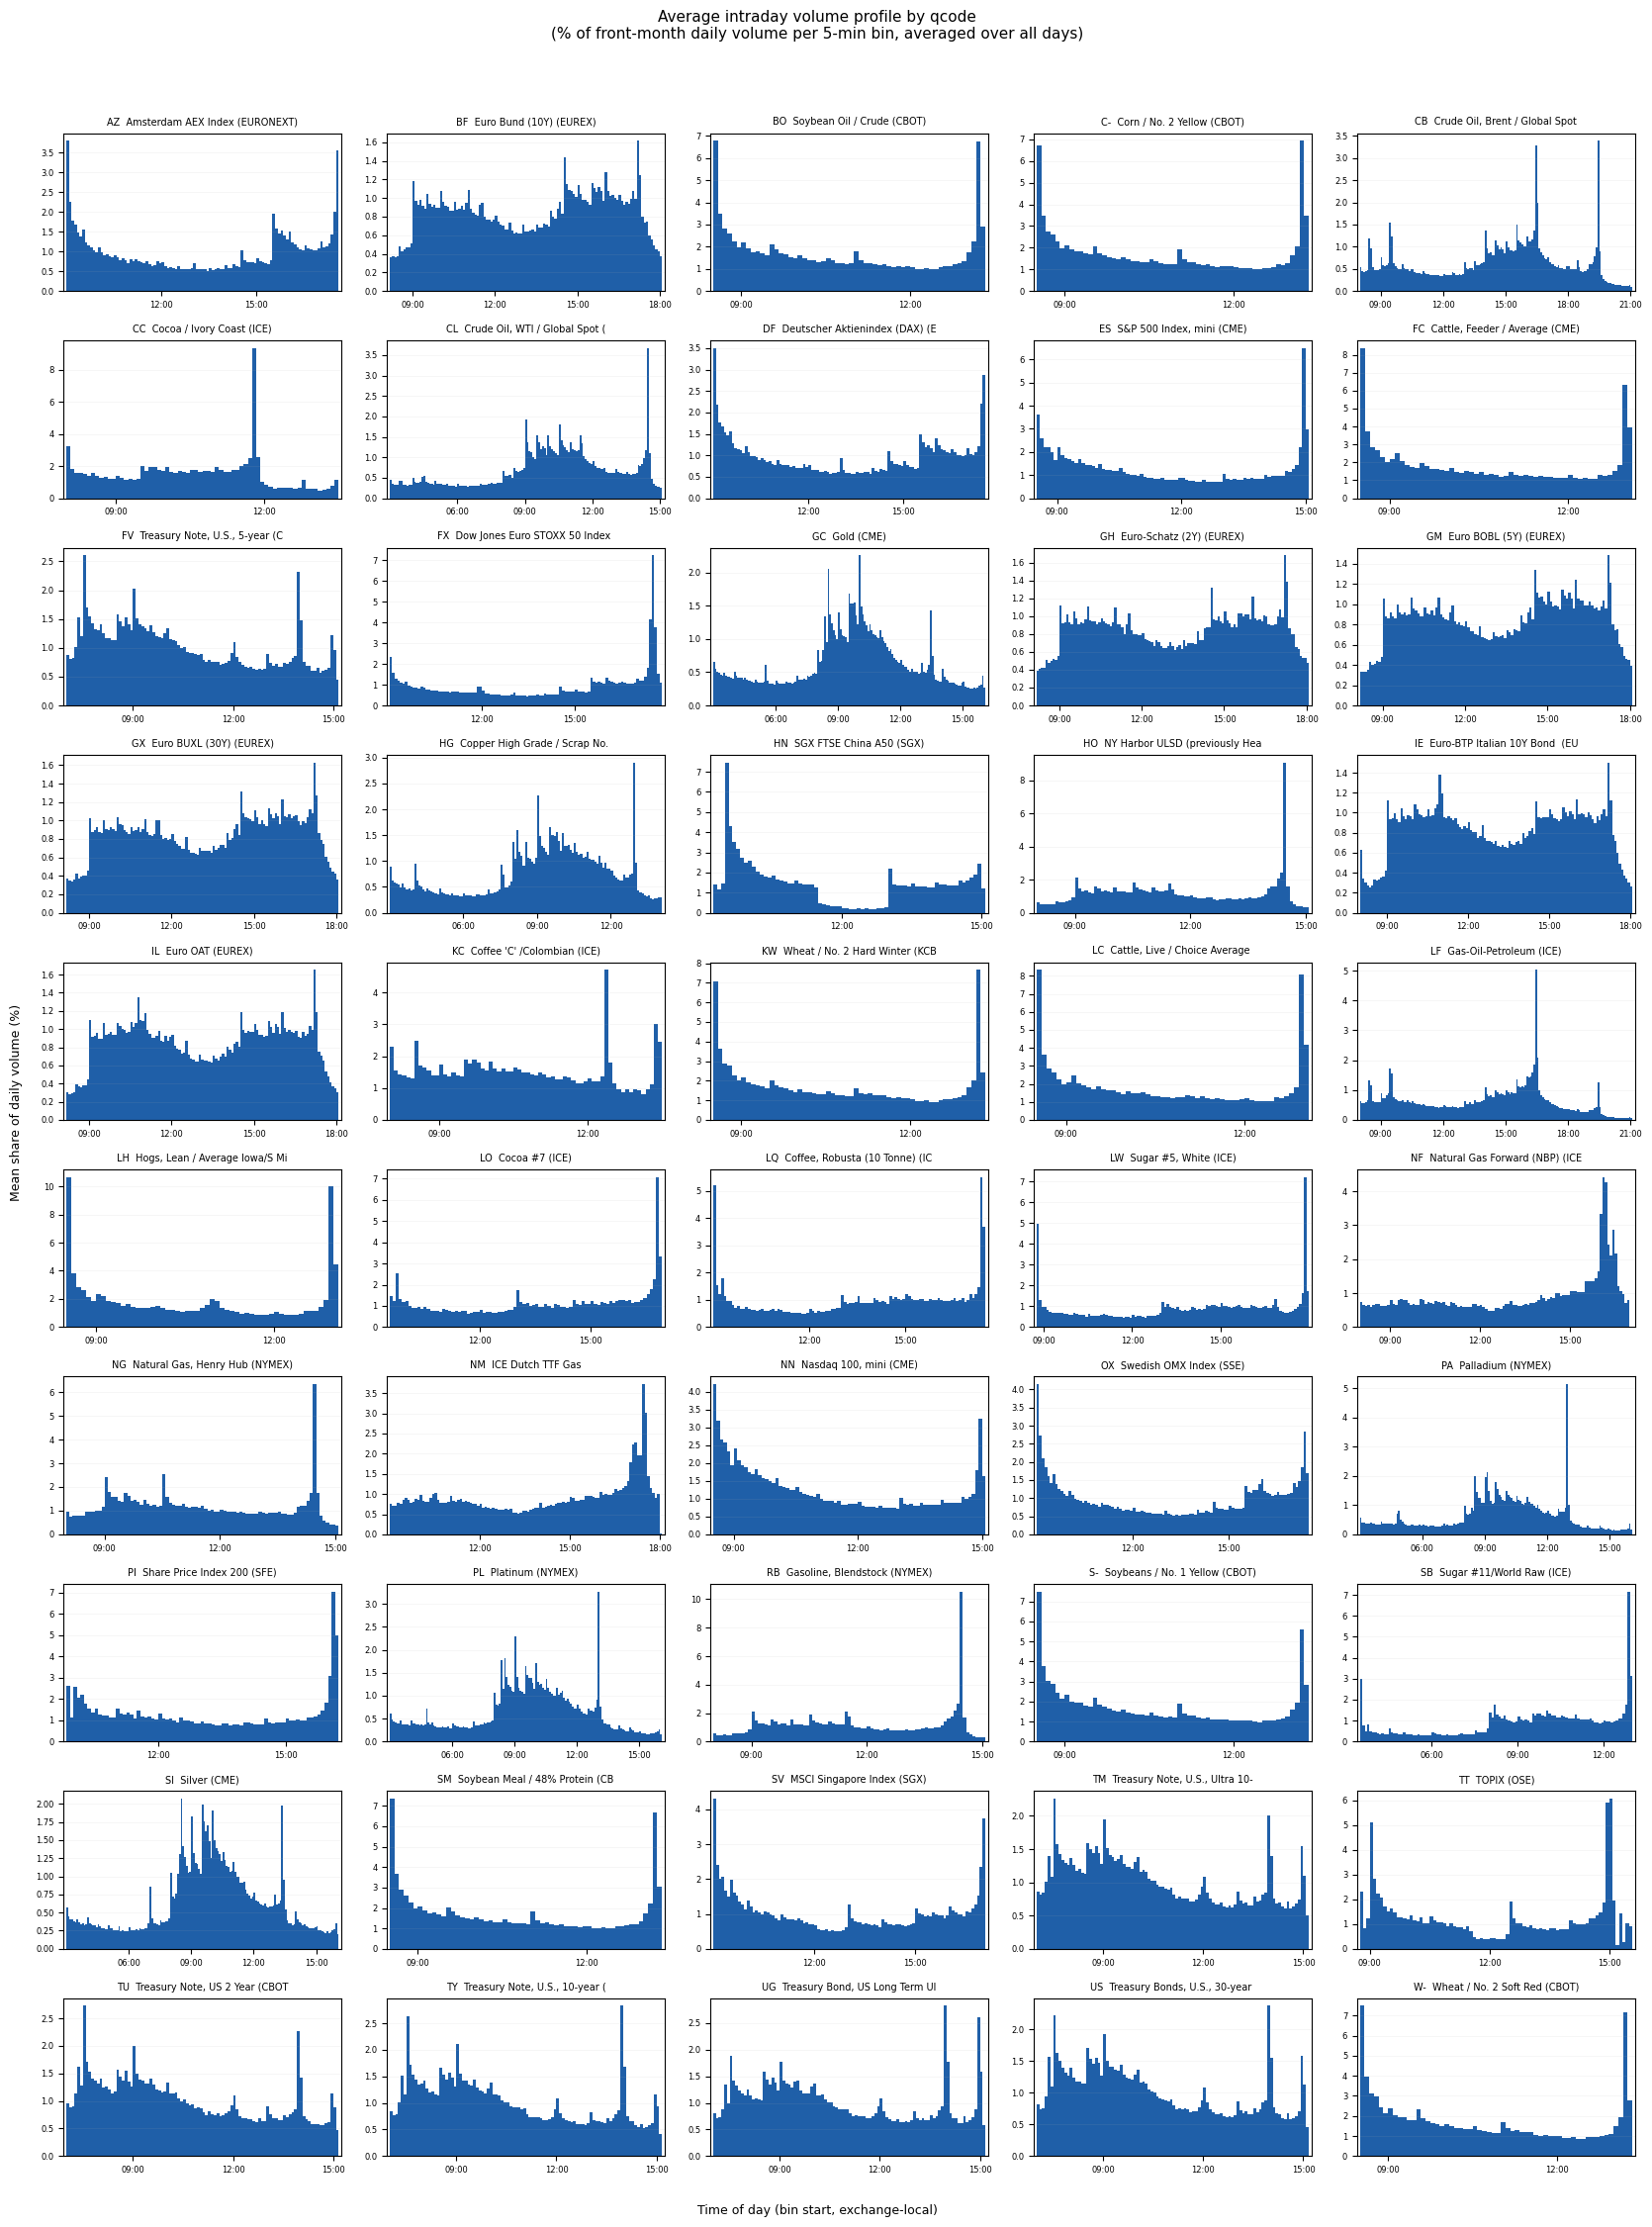

In [32]:
# one panel per qcode: mean share of daily volume vs time of day (histogram)
qm = pl.read_csv("data/raw/qcode_mapping.csv")
desc = dict(zip(qm["qcode"], qm["description"]))

qcodes = profile["qcode"].unique().sort().to_list()
ncols = 5
nrows = (len(qcodes) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.4, nrows * 2.3), squeeze=False)

for i, q in enumerate(qcodes):
    ax = axes[i // ncols][i % ncols]
    sub = profile.filter(pl.col("qcode") == q).sort("minutes")
    x, y = sub["minutes"], sub["mean_proportion"] * 100
    ax.bar(x, y, width=5, align="edge", color="#1f5fa8", edgecolor="none")
    ax.set_title(f"{q}  {desc.get(q, '')}"[:34], fontsize=7)
    ax.tick_params(labelsize=6)
    lo, hi = sub["minutes"].min(), sub["minutes"].max()
    ticks = list(range(((lo // 180) + 1) * 180, hi + 1, 180))
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{t // 60:02d}:{t % 60:02d}" for t in ticks])
    ax.margins(x=0.01)
    ax.grid(True, axis="y", alpha=0.2, lw=0.4)

for j in range(len(qcodes), nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")

fig.suptitle(
    "Average intraday volume profile by qcode\n"
    "(% of front-month daily volume per 5-min bin, averaged over all days)",
    fontsize=11,
)
fig.supxlabel("Time of day (bin start, exchange-local)", fontsize=9)
fig.supylabel("Mean share of daily volume (%)", fontsize=9)
fig.tight_layout(rect=(0.01, 0.01, 1, 0.96))
plt.show()


---

## Average intraday volatility profile per qcode

The same construction as the volume profile, but for **volatility**. Each 5-minute bin's variance is estimated with the **Rogers–Satchell (RS)** estimator from the bin's OHLC:

$$\sigma_{RS}^2 = \underbrace{\ln\!\left(\frac{H}{C}\right)\ln\!\left(\frac{H}{O}\right)}_{\text{upward component}} + \underbrace{\ln\!\left(\frac{L}{C}\right)\ln\!\left(\frac{L}{O}\right)}_{\text{downward component}}$$

Both components are ≥ 0 (since `H ≥ O, C` and `L ≤ O, C`), so $\sigma_{RS}^2 \ge 0$. For each qcode we average the bin variance across all trading days — bin by bin — giving one intraday volatility profile per qcode in **absolute RS-variance units** (no normalisation; the curve does *not* sum to 1).

**Two outlier safeguards before averaging:**

1. **Bad-tick drop.** A handful of bins carry a corrupted OHLC price (a misplaced decimal makes one of O/H/L/C 10–100× off, or a stray near-zero print). Because RS uses logs of price ratios, one such bin produces a fake variance millions of times larger than a real bar. A 5-minute bar with a **high/low ratio above 2** (>100% range) is physically implausible here, so those bins are dropped as bad data and displayed below so the removal is auditable.
2. **Winsorisation.** Even after that, a few legitimate-but-extreme days can dominate a bin's mean. So within each **(qcode, time-of-day) slot** we **winsorise the cross-day RS variance to its central 95% (the 2.5–97.5 percentiles)** before averaging — clipping each slot against *its own* history, which tames day-specific spikes while preserving the genuine time-of-day shape (a high-variance bin isn't clipped down to a low-variance bin's level).

`BINNED_DATA` holds one security per `(qcode, date)` — the front-month — so no contract selection is needed. The result is one curve per qcode: *typical (winsorised) return variance realised in each 5-min bin*.

In [53]:
import polars as pl
import matplotlib.pyplot as plt

# full table so the bad-tick rows below can show every field (signed volume,
# twa bid/ask, etc.)
binned = pl.read_csv("data/raw/binned_data.csv")

# per-bin Rogers-Satchell variance: ln(H/C)ln(H/O) + ln(L/C)ln(L/O)
rs_var = (
    (pl.col("high") / pl.col("close")).log() * (pl.col("high") / pl.col("open")).log()
    + (pl.col("low") / pl.col("close")).log() * (pl.col("low") / pl.col("open")).log()
)
price_cols = ["open", "high", "low", "close"]

# bins with all four prices present and positive (logs must be defined), plus
# the high/low ratio used to flag corrupted-OHLC bad ticks
bins_ok = (
    binned
    .filter(pl.all_horizontal([pl.col(c).is_not_null() & (pl.col(c) > 0) for c in price_cols]))
    .with_columns(
        rs_var.alias("rs_var"),
        (pl.col("high") / pl.col("low")).alias("hi_lo_ratio"),
    )
)

# (1) drop bad ticks: a 5-min bar with >100% high/low range is implausible here
MAX_HL_RATIO = 2.0
bad_bins = bins_ok.filter(pl.col("hi_lo_ratio") > MAX_HL_RATIO).sort("hi_lo_ratio", descending=True)
vol = bins_ok.filter(pl.col("hi_lo_ratio") <= MAX_HL_RATIO)
print(f"dropped {bad_bins.height} bad-tick bins (high/low > {MAX_HL_RATIO}) of {bins_ok.height:,}")

# (2) winsorise each (qcode, time-of-day) slot's cross-day RS variance to its
# central 95% (2.5-97.5 pct) before averaging, so a few extreme days can't
# dominate that bin's mean
WINSOR_LO, WINSOR_HI = 0.025, 0.975
slot = ["qcode", "bin_start_time"]
lo = pl.col("rs_var").quantile(WINSOR_LO).over(slot)
hi = pl.col("rs_var").quantile(WINSOR_HI).over(slot)
vol = vol.with_columns(pl.col("rs_var").clip(lo, hi).alias("rs_var_w"))

# average the winsorised bin variance across all trading days, bin by bin
# (no normalisation — absolute RS-variance units)
vol_profile = (
    vol
    .group_by(slot)
    .agg(pl.col("rs_var_w").mean().alias("mean_rs_var"))
    .with_columns(
        (pl.col("bin_start_time").str.slice(0, 2).cast(pl.Int32) * 60
         + pl.col("bin_start_time").str.slice(3, 2).cast(pl.Int32)).alias("minutes")
    )
    .select("qcode", "bin_start_time", "minutes", "mean_rs_var")
    .sort("qcode", "minutes")
)
vol_profile.head()

dropped 39 bad-tick bins (high/low > 2.0) of 13,037,793


qcode,bin_start_time,minutes,mean_rs_var
str,str,i32,f64
"""AZ""","""09:00:00.000000000""",540,0.000003
"""AZ""","""09:05:00.000000000""",545,0.000002
"""AZ""","""09:10:00.000000000""",550,0.000001
"""AZ""","""09:15:00.000000000""",555,0.000001
"""AZ""","""09:20:00.000000000""",560,8.9851e-7


In [54]:
# the bad-tick bins removed above (corrupted OHLC), worst first — full record of
# every field. Note how one of O/H/L/C is 10-100x off the others (or a near-zero
# print), while volume / signed_volume / twa_bid / twa_ask look normal.
lead = [
    "qcode", "security", "publication_date", "bin_start_time",
    "open", "high", "low", "close", "hi_lo_ratio", "rs_var",
    "volume", "signed_volume", "trade_count", "vwap", "twa_bid", "twa_ask",
]
ordered = lead + [c for c in bad_bins.columns if c not in lead]
with pl.Config(tbl_rows=bad_bins.height, tbl_cols=-1):
    display(bad_bins.select(ordered))

qcode,security,publication_date,bin_start_time,open,high,low,close,hi_lo_ratio,rs_var,volume,signed_volume,trade_count,vwap,twa_bid,twa_ask,gmt_offset_hours,twa_bid_size,twa_ask_size,bid_size_start,bid_size_end,ask_size_start,ask_size_end,bid_start,bid_end,ask_start,ask_end
str,str,str,str,f64,f64,f64,f64,f64,f64,i64,i64,i64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,f64,f64,f64,f64
"""RB""","""XB2016X Comdty""","""2016-10-26""","""14:00:00.000000000""",1.4757,1.4778,0.0001,1.4778,14778.0,92.163529,37,-31,9,0.35927,1.476068,1.476521,-4.0,1.966753,1.749577,1,3,2,4,1.4756,1.4773,1.4759,1.4778
"""RB""","""XB2016Q Comdty""","""2016-07-28""","""14:00:00.000000000""",0.0001,1.306,0.0001,1.306,13060.0,0.0,51,-43,7,0.153694,1.305871,1.306541,-4.0,1.39337,1.7455,1,3,1,2,1.3069,1.3055,1.3078,1.3064
"""OX""","""QC2017Z Index""","""2017-11-23""","""13:15:00.000000000""",1615.25,1615.5,13.15,1615.0,122.851711,23.143276,215,-142,48,1391.672093,1615.073783,1615.354933,1.0,42.832453,41.32209,57,29,43,38,1615.25,1615.0,1615.5,1615.25
"""OX""","""QC2017Z Index""","""2017-11-23""","""13:30:00.000000000""",1615.5,1615.5,13.15,1615.25,122.851711,23.144765,234,-6,43,1409.625,1615.002507,1615.262985,1.0,32.300747,32.421657,7,37,49,50,1615.5,1615.25,1615.75,1615.5
"""OX""","""QC2018V Index""","""2018-10-03""","""15:15:00.000000000""",1671.0,167275.0,1669.75,1670.0,100.179668,21.219992,7008,5906,197,96194.258169,1670.434397,1670.702906,2.0,30.39804,49.808447,36,13,56,58,1671.0,1669.75,1671.25,1670.0
"""OX""","""QC2019M Index""","""2019-06-11""","""16:00:00.000000000""",1595.0,1596.25,15.95,1596.0,100.07837,21.210479,1317,-205,181,1055.839787,1595.630117,1595.886064,2.0,37.421623,47.01414,46,19,26,54,1594.75,1595.75,1595.0,1596.0
"""OX""","""QC2024G Index""","""2024-01-30""","""15:25:00.000000000""",2370.5,2371.0,24.5,2369.5,96.77551,20.902929,606,47,394,2334.97401,2369.64541,2369.896968,1.0,23.911633,21.156893,29,30,8,8,2370.25,2369.25,2370.5,2369.5
"""CL""","""CL2020K Comdty""","""2020-04-20""","""13:55:00.000000000""",0.82,0.86,0.01,0.69,86.0,18.669008,1540,-456,741,0.293234,0.318789,0.3700003,-4.0,3.225063,2.632743,2,1,3,4,0.84,0.6,0.93,0.7
"""CL""","""CL2020K Comdty""","""2020-04-20""","""14:00:00.000000000""",0.61,0.7,0.03,0.37,23.333333,7.655466,794,-262,391,0.271058,0.322584,0.3680749,-4.0,2.549037,2.692943,1,1,4,1,0.6,0.37,0.7,0.4


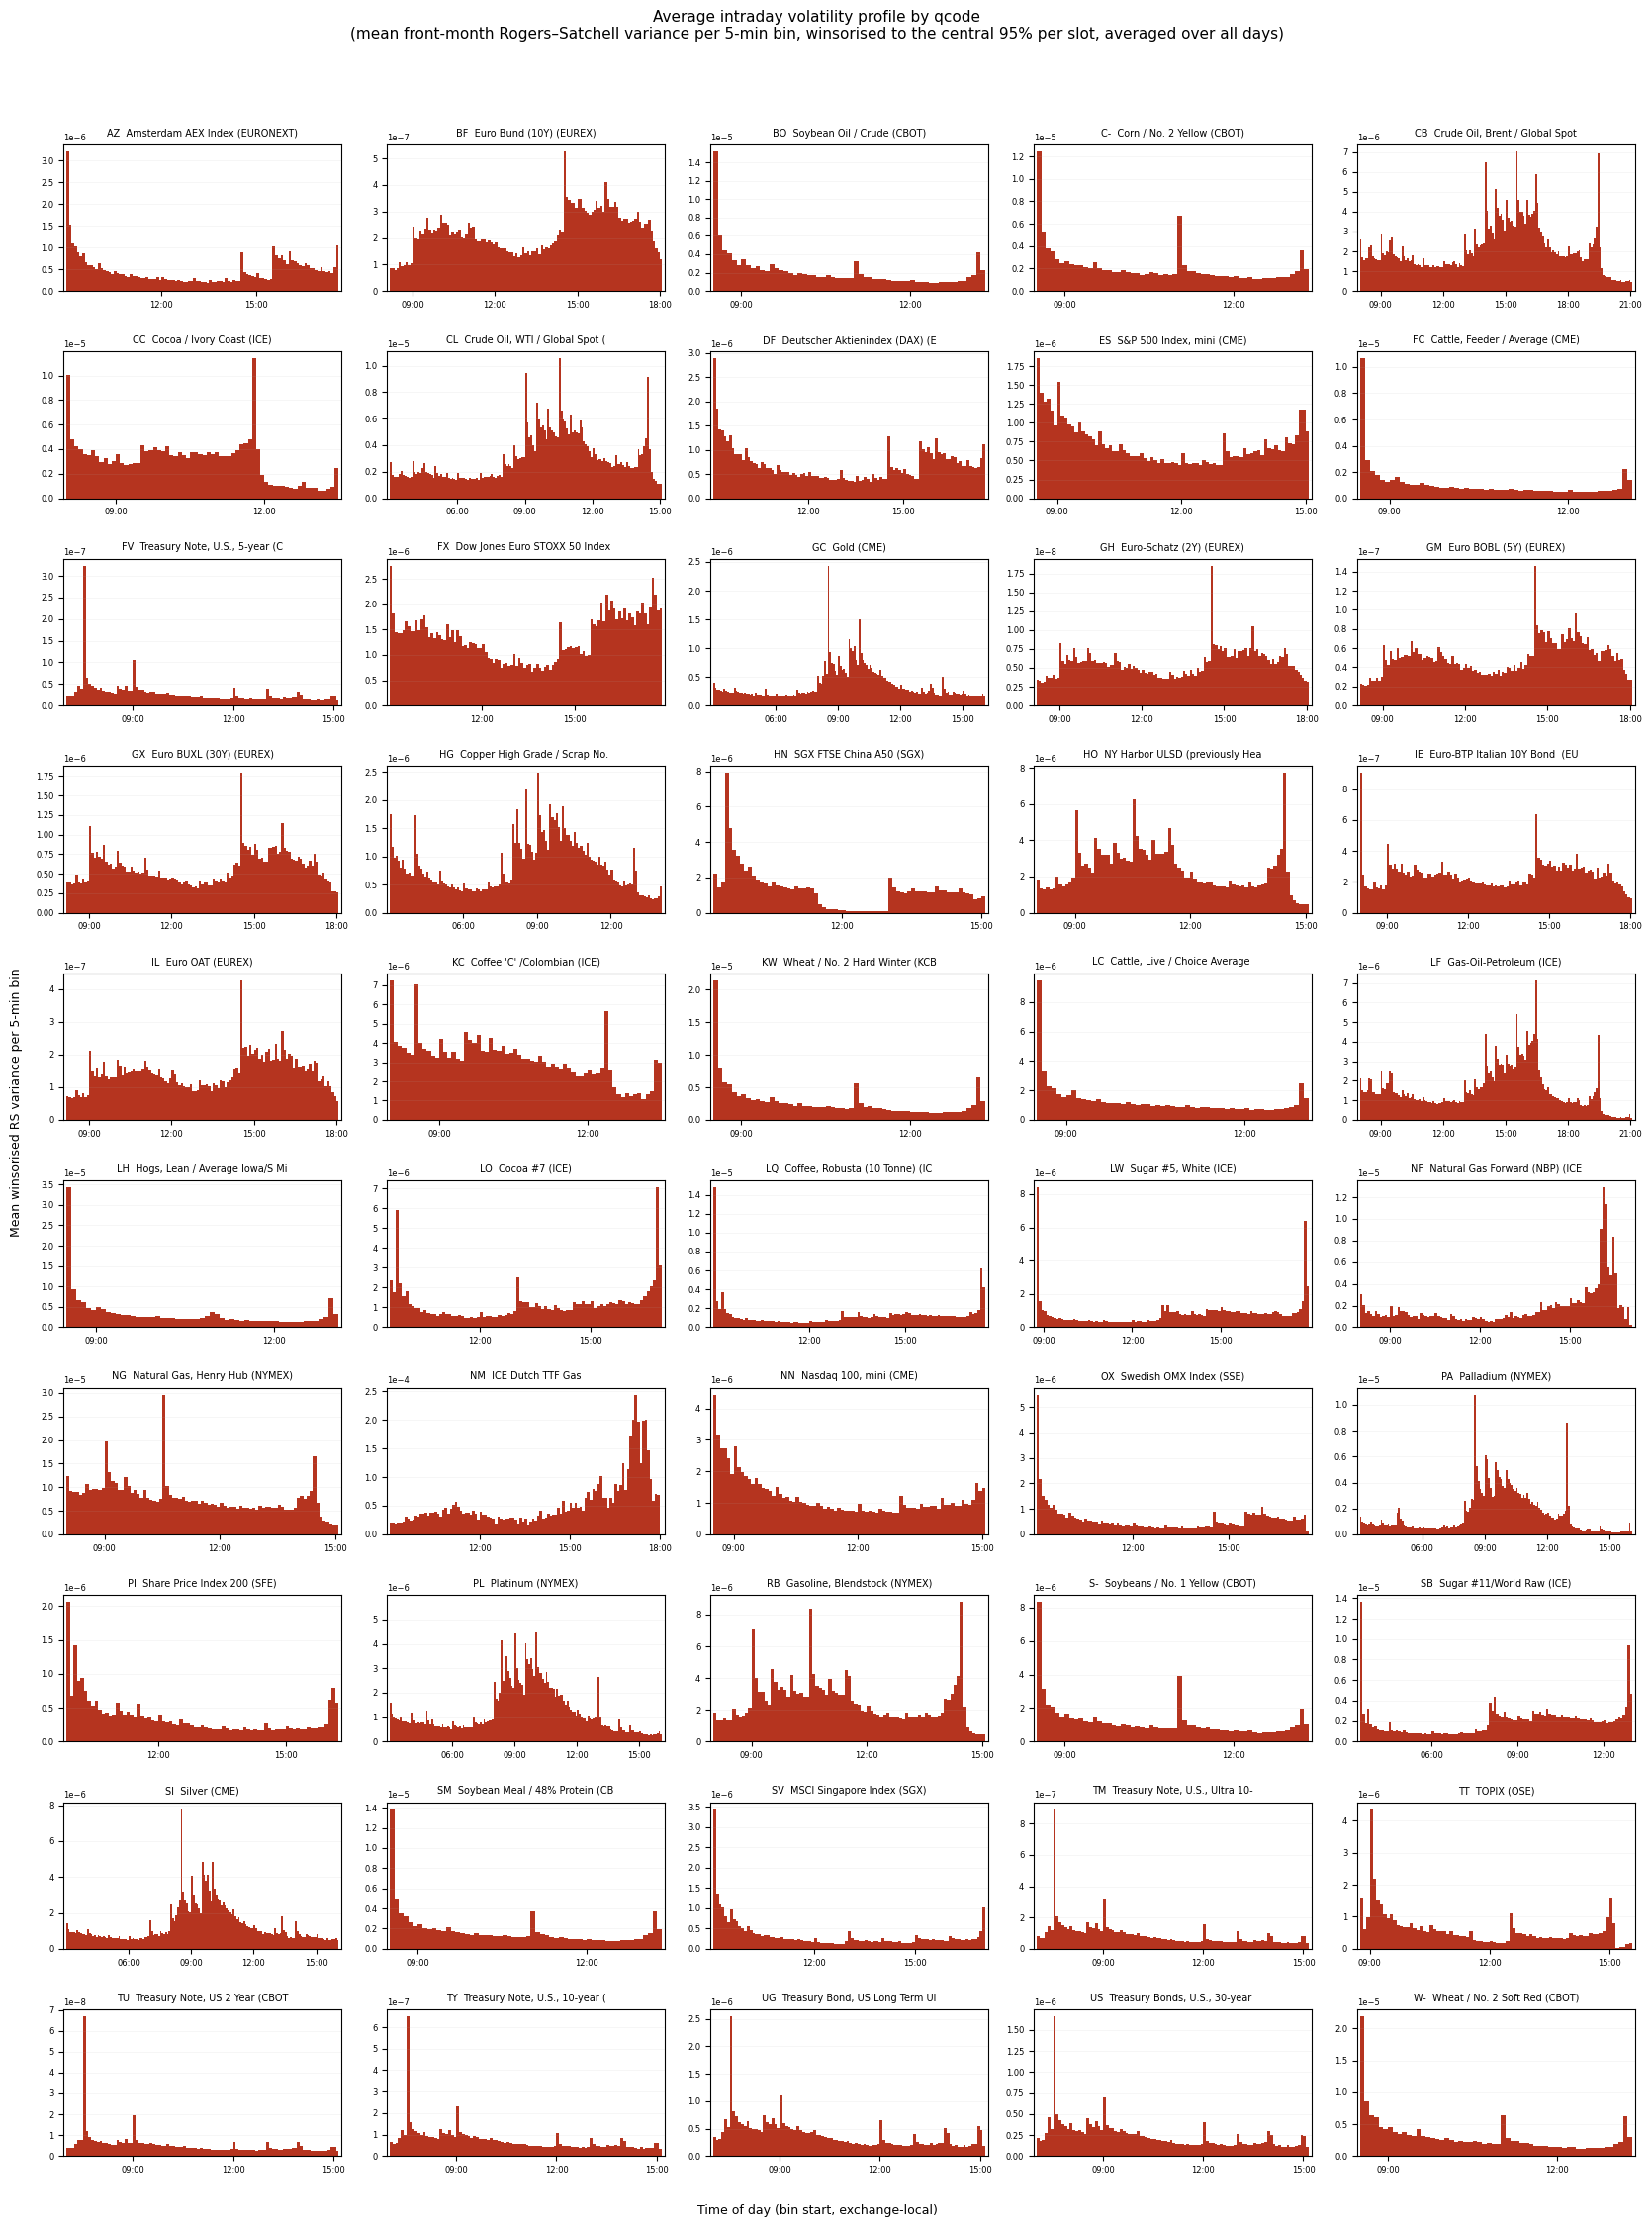

In [55]:
# one panel per qcode: mean (winsorised) RS variance vs time of day (histogram)
qm = pl.read_csv("data/raw/qcode_mapping.csv")
desc = dict(zip(qm["qcode"], qm["description"]))

qcodes = vol_profile["qcode"].unique().sort().to_list()
ncols = 5
nrows = (len(qcodes) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.4, nrows * 2.3), squeeze=False)

for i, q in enumerate(qcodes):
    ax = axes[i // ncols][i % ncols]
    sub = vol_profile.filter(pl.col("qcode") == q).sort("minutes")
    x, y = sub["minutes"], sub["mean_rs_var"]
    ax.bar(x, y, width=5, align="edge", color="#b5341f", edgecolor="none")
    ax.set_title(f"{q}  {desc.get(q, '')}"[:34], fontsize=7)
    ax.tick_params(labelsize=6)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_fontsize(6)
    lo, hi = sub["minutes"].min(), sub["minutes"].max()
    ticks = list(range(((lo // 180) + 1) * 180, hi + 1, 180))
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{t // 60:02d}:{t % 60:02d}" for t in ticks])
    ax.margins(x=0.01)
    ax.grid(True, axis="y", alpha=0.2, lw=0.4)

for j in range(len(qcodes), nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")

fig.suptitle(
    "Average intraday volatility profile by qcode\n"
    "(mean front-month Rogers–Satchell variance per 5-min bin, winsorised to the "
    "central 95% per slot, averaged over all days)",
    fontsize=11,
)
fig.supxlabel("Time of day (bin start, exchange-local)", fontsize=9)
fig.supylabel("Mean winsorised RS variance per 5-min bin", fontsize=9)
fig.tight_layout(rect=(0.01, 0.01, 1, 0.96))
plt.show()

---

## Average intraday spread profile per qcode

Same construction once more, now for the **quoted spread** — `twa_ask - twa_bid` per 5-minute bin (the time-weighted average ask minus bid). This is exactly the spread `execution.py` charges in its fill model (`fill_price = vwap ± x · spread`), so its intraday shape is what drives execution friction through the day.

For each qcode we average the per-bin spread across all trading days, bin by bin, in the instrument's **own price units** (panels autoscale). Same winsorisation as the volatility profile: within each **(qcode, time-of-day) slot** the cross-day spread is clipped to its central 95% (2.5–97.5 pct) before averaging, so occasional quote blow-outs don't dominate a bin's mean.

No high/low bad-tick filter is needed here — the spread comes from the bid/ask snapshots, which stayed clean even in the corrupted-OHLC bins (those bad ticks lived in `high`/`low`/`vwap`, not the quotes).

In [50]:
import polars as pl
import matplotlib.pyplot as plt

spr = pl.read_csv("data/raw/binned_data.csv").select(
    "qcode", "publication_date", "bin_start_time", "twa_bid", "twa_ask"
)
spr = (
    spr.filter(pl.col("twa_bid").is_not_null() & pl.col("twa_ask").is_not_null())
       .with_columns((pl.col("twa_ask") - pl.col("twa_bid")).alias("spread"))
       .filter(pl.col("spread") >= 0)          # drop any crossed-quote bins
)

# winsorise each (qcode, time-of-day) slot's cross-day spread to its central 95%
WINSOR_LO, WINSOR_HI = 0.025, 0.975
slot = ["qcode", "bin_start_time"]
lo = pl.col("spread").quantile(WINSOR_LO).over(slot)
hi = pl.col("spread").quantile(WINSOR_HI).over(slot)
spr = spr.with_columns(pl.col("spread").clip(lo, hi).alias("spread_w"))

# average the winsorised spread across all trading days, bin by bin (price units)
spread_profile = (
    spr.group_by(slot)
       .agg(pl.col("spread_w").mean().alias("mean_spread"))
       .with_columns(
           (pl.col("bin_start_time").str.slice(0, 2).cast(pl.Int32) * 60
            + pl.col("bin_start_time").str.slice(3, 2).cast(pl.Int32)).alias("minutes")
       )
       .select("qcode", "bin_start_time", "minutes", "mean_spread")
       .sort("qcode", "minutes")
)
spread_profile.head()

qcode,bin_start_time,minutes,mean_spread
str,str,i32,f64
"""AZ""","""09:00:00.000000000""",540,0.135002
"""AZ""","""09:05:00.000000000""",545,0.109569
"""AZ""","""09:10:00.000000000""",550,0.102748
"""AZ""","""09:15:00.000000000""",555,0.099345
"""AZ""","""09:20:00.000000000""",560,0.096216


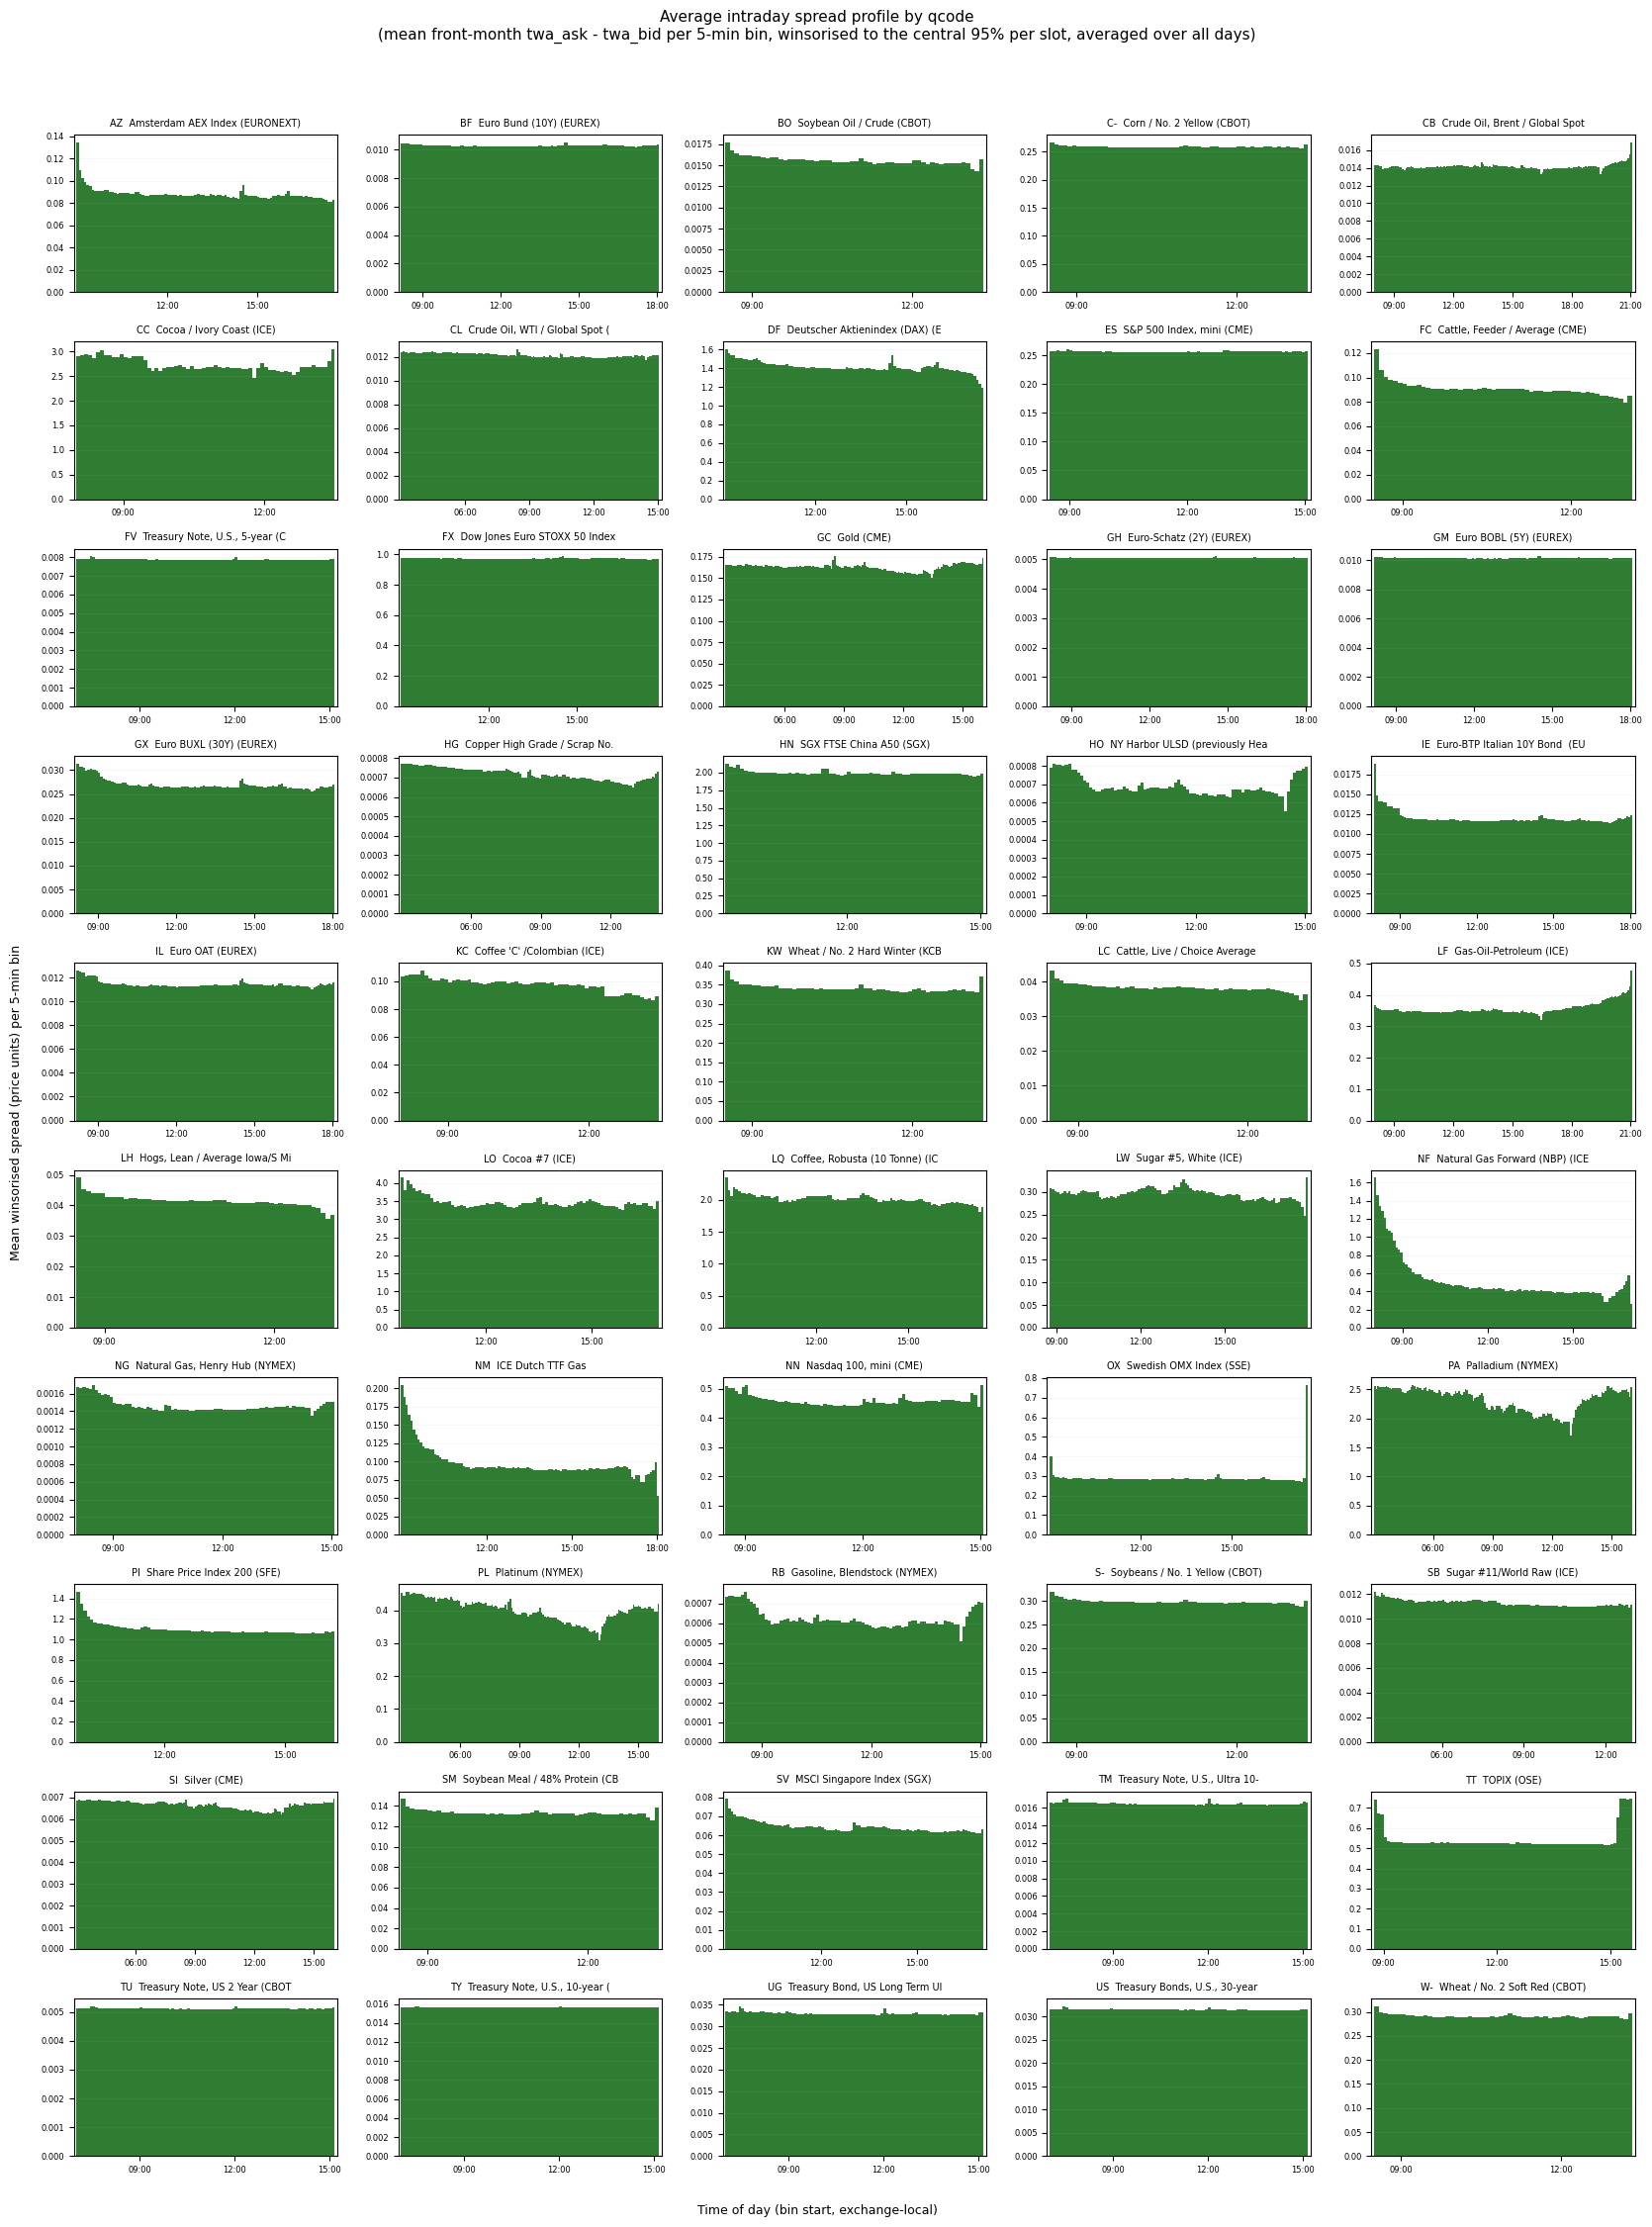

In [51]:
# one panel per qcode: mean (winsorised) quoted spread vs time of day (histogram)
qm = pl.read_csv("data/raw/qcode_mapping.csv")
desc = dict(zip(qm["qcode"], qm["description"]))

qcodes = spread_profile["qcode"].unique().sort().to_list()
ncols = 5
nrows = (len(qcodes) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.4, nrows * 2.3), squeeze=False)

for i, q in enumerate(qcodes):
    ax = axes[i // ncols][i % ncols]
    sub = spread_profile.filter(pl.col("qcode") == q).sort("minutes")
    x, y = sub["minutes"], sub["mean_spread"]
    ax.bar(x, y, width=5, align="edge", color="#2e7d32", edgecolor="none")
    ax.set_title(f"{q}  {desc.get(q, '')}"[:34], fontsize=7)
    ax.tick_params(labelsize=6)
    lo, hi = sub["minutes"].min(), sub["minutes"].max()
    ticks = list(range(((lo // 180) + 1) * 180, hi + 1, 180))
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{t // 60:02d}:{t % 60:02d}" for t in ticks])
    ax.margins(x=0.01)
    ax.grid(True, axis="y", alpha=0.2, lw=0.4)

for j in range(len(qcodes), nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")

fig.suptitle(
    "Average intraday spread profile by qcode\n"
    "(mean front-month twa_ask - twa_bid per 5-min bin, winsorised to the "
    "central 95% per slot, averaged over all days)",
    fontsize=11,
)
fig.supxlabel("Time of day (bin start, exchange-local)", fontsize=9)
fig.supylabel("Mean winsorised spread (price units) per 5-min bin", fontsize=9)
fig.tight_layout(rect=(0.01, 0.01, 1, 0.96))
plt.show()

In [ ]:
# one panel per qcode: mean RAW (un-winsorised) quoted spread vs time of day
# same as the cell above, but WITHOUT the central-95% winsorisation step
spr_raw = pl.read_csv("data/raw/binned_data.csv").select(
    "qcode", "publication_date", "bin_start_time", "twa_bid", "twa_ask"
)
spr_raw = (
    spr_raw.filter(pl.col("twa_bid").is_not_null() & pl.col("twa_ask").is_not_null())
           .with_columns((pl.col("twa_ask") - pl.col("twa_bid")).alias("spread"))
           .filter(pl.col("spread") >= 0)          # drop any crossed-quote bins
)

# average the RAW spread across all trading days, bin by bin (no winsorisation)
spread_profile_raw = (
    spr_raw.group_by(["qcode", "bin_start_time"])
           .agg(pl.col("spread").mean().alias("mean_spread"))
           .with_columns(
               (pl.col("bin_start_time").str.slice(0, 2).cast(pl.Int32) * 60
                + pl.col("bin_start_time").str.slice(3, 2).cast(pl.Int32)).alias("minutes")
           )
           .select("qcode", "bin_start_time", "minutes", "mean_spread")
           .sort("qcode", "minutes")
)

qm = pl.read_csv("data/raw/qcode_mapping.csv")
desc = dict(zip(qm["qcode"], qm["description"]))

qcodes = spread_profile_raw["qcode"].unique().sort().to_list()
ncols = 5
nrows = (len(qcodes) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.4, nrows * 2.3), squeeze=False)

for i, q in enumerate(qcodes):
    ax = axes[i // ncols][i % ncols]
    sub = spread_profile_raw.filter(pl.col("qcode") == q).sort("minutes")
    x, y = sub["minutes"], sub["mean_spread"]
    ax.bar(x, y, width=5, align="edge", color="#2e7d32", edgecolor="none")
    ax.set_title(f"{q}  {desc.get(q, '')}"[:34], fontsize=7)
    ax.tick_params(labelsize=6)
    lo, hi = sub["minutes"].min(), sub["minutes"].max()
    ticks = list(range(((lo // 180) + 1) * 180, hi + 1, 180))
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{t // 60:02d}:{t % 60:02d}" for t in ticks])
    ax.margins(x=0.01)
    ax.grid(True, axis="y", alpha=0.2, lw=0.4)

for j in range(len(qcodes), nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")

fig.suptitle(
    "Average intraday spread profile by qcode - NO winsorisation
"
    "(mean front-month twa_ask - twa_bid per 5-min bin, raw mean over all days)",
    fontsize=11,
)
fig.supxlabel("Time of day (bin start, exchange-local)", fontsize=9)
fig.supylabel("Mean RAW spread (price units) per 5-min bin", fontsize=9)
fig.tight_layout(rect=(0.01, 0.01, 1, 0.96))
plt.show()